# Import libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display plots properly
%matplotlib inline

# Set visualization style
sns.set_style("whitegrid")

# Load dataset

In [3]:
# Load cleaned retail store dataset

df = pd.read_csv("../data/cleaned/retail_store_sales_cleaned.csv")


In [4]:
# Display first 5 rows
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


# Dataset overview

In [5]:
# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (12575, 11)

Columns:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']

Data Types:
Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied       bool
dtype: object

Statistical Summary:


,Price Per Unit,Quantity,Total Spent
count,12575.000000,12575.000000,12575.000000
mean,23.348191,5.558648,130.208111
std,10.480413,2.790160,93.580667
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,52.000000
50%,23.000000,6.000000,110.000000
75%,32.000000,8.000000,192.000000
max,41.000000,10.000000,410.000000


# Check missing values

In [6]:
# Calculate missing values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64


# Sales by Category

Category
Butchers                              218153.0
Electric household essentials         215297.5
Beverages                             206854.5
Furniture                             205390.0
Food                                  205225.0
Computers and electric accessories    202023.5
Patisserie                            194531.5
Milk Products                         189892.0
Name: Total Spent, dtype: float64


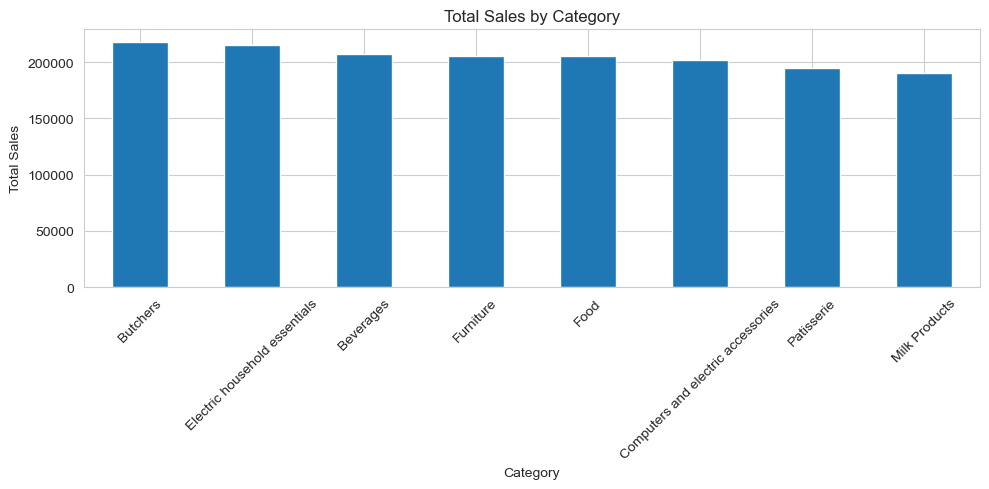

In [7]:
# Calculate total sales by category

category_sales = df.groupby("Category")["Total Spent"].sum().sort_values(ascending=False)

print(category_sales)

# Create visualization
plt.figure(figsize=(10, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

# Save chart
plt.savefig("../visualizations/real_world_sales_by_category.png")

plt.show()

# Payment Method Analysis

Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64


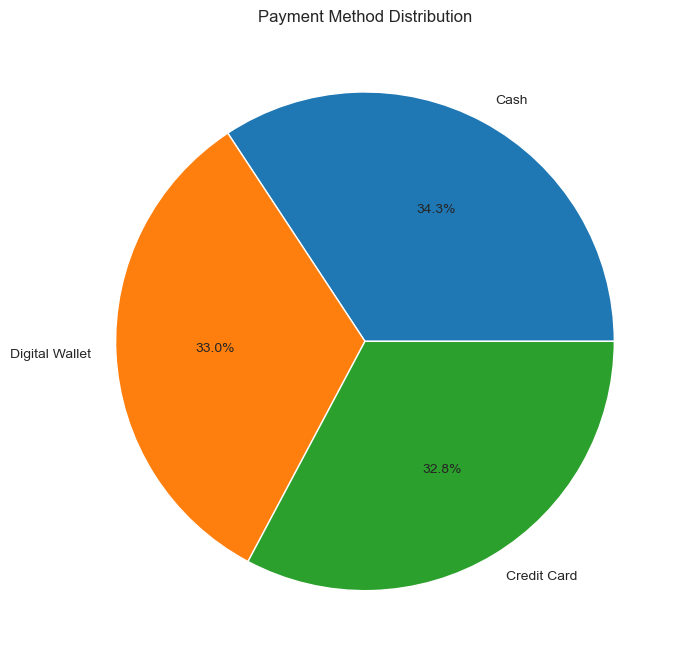

In [8]:
# Count transactions by payment method

payment_counts = df["Payment Method"].value_counts()

print(payment_counts)

# Create pie chart
plt.figure(figsize=(7, 7))

payment_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")
plt.ylabel("")

plt.tight_layout()

# Save chart
plt.savefig("../visualizations/real_world_payment_method.png")

plt.show()

# Location Analysis

Location
Online      6354
In-store    6221
Name: count, dtype: int64


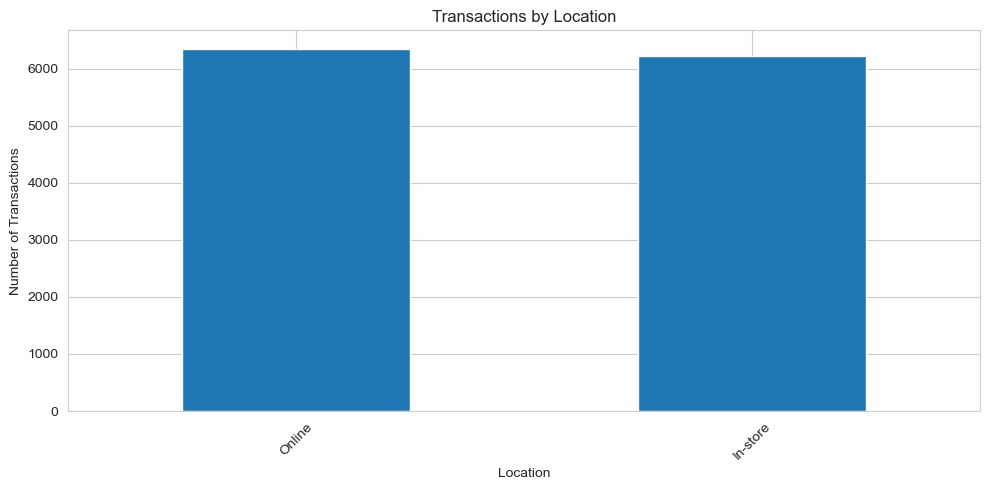

In [9]:
# Count transactions by location

location_counts = df["Location"].value_counts()

print(location_counts)

# Create bar chart
plt.figure(figsize=(10, 5))

location_counts.plot(kind="bar")

plt.title("Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualizations/real_world_location.png")

plt.show()

# Monthly Sales Trend

Month
2022-01    56271.5
2022-02    46268.5
2022-03    43225.0
2022-04    42584.0
2022-05    42066.5
2022-06    44481.0
2022-07    47453.5
2022-08    43415.5
2022-09    47541.5
2022-10    40422.0
2022-11    45366.5
2022-12    41507.0
2023-01    49354.5
2023-02    41392.5
2023-03    41405.5
2023-04    41056.5
2023-05    42490.5
2023-06    44061.0
2023-07    48191.5
2023-08    40080.0
2023-09    43028.0
2023-10    40320.0
2023-11    38715.0
2023-12    45406.0
2024-01    51043.5
2024-02    40001.0
2024-03    45213.5
2024-04    48524.0
2024-05    47519.5
2024-06    47364.0
2024-07    42719.0
2024-08    46161.0
2024-09    43952.5
2024-10    45085.5
2024-11    46020.0
2024-12    50692.5
2025-01    26967.5
Name: Total Spent, dtype: float64


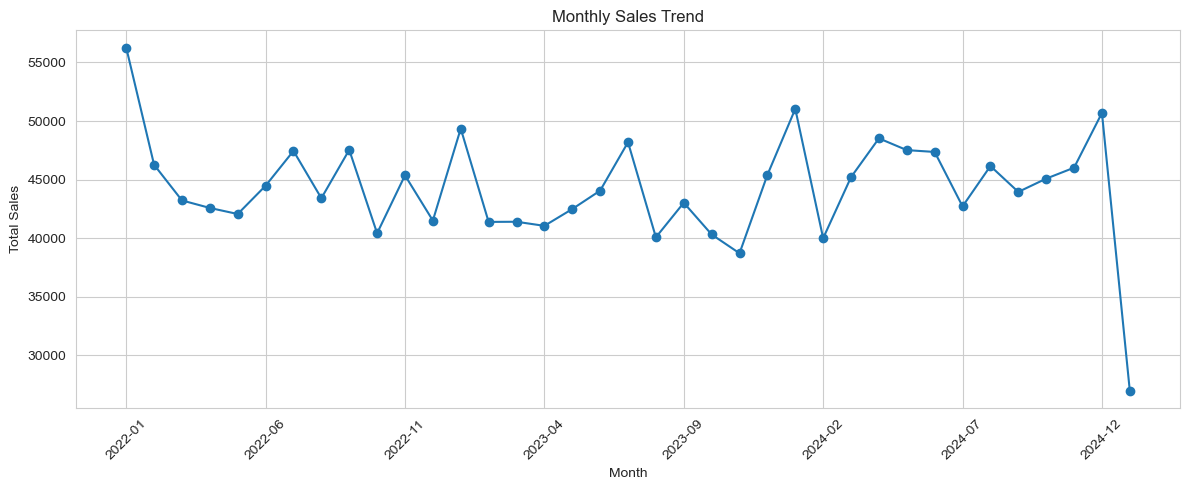

In [10]:
# Convert transaction date to datetime

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

# Extract month
df["Month"] = df["Transaction Date"].dt.to_period("M").astype(str)

# Calculate monthly sales
monthly_sales = df.groupby("Month")["Total Spent"].sum()

print(monthly_sales)

# Create line chart
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualizations/real_world_monthly_sales.png")

plt.show()

# Correlation Analysis

                Price Per Unit  Quantity  Total Spent
Price Per Unit        1.000000  0.011306     0.625595
Quantity              0.011306  1.000000     0.703938
Total Spent           0.625595  0.703938     1.000000


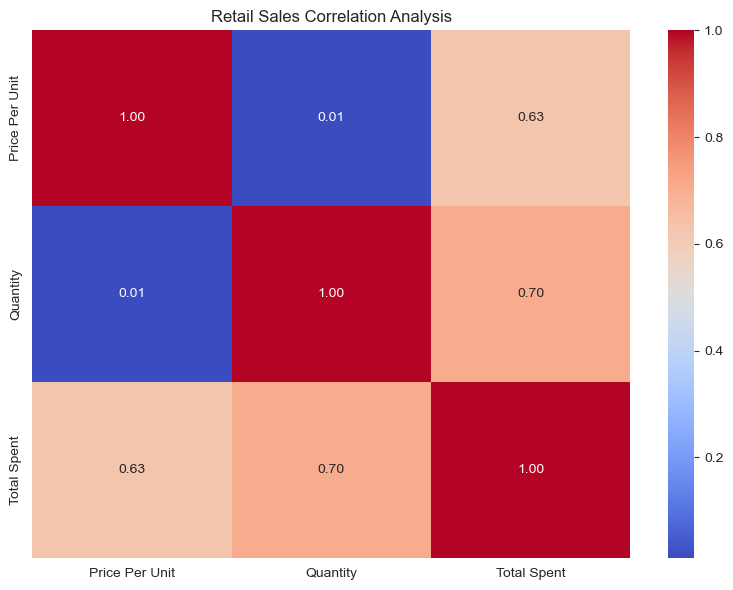

In [11]:
# Select numerical columns

numeric_columns = [
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]

# Calculate correlation
correlation = df[numeric_columns].corr()

print(correlation)

# Create heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Retail Sales Correlation Analysis")

plt.tight_layout()

plt.savefig("../visualizations/real_world_correlation.png")

plt.show()

# Machine Learning Prediction

In [12]:
# Select features

X = df[
    [
        "Price Per Unit",
        "Quantity"
    ]
]

# Select target
y = df["Total Spent"]

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (10060, 2)
Testing Data: (2515, 2)


# Train Random Forest

In [13]:
# Create Random Forest Regression model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


# Make Predictions

In [14]:
# Predict sales on test data

y_pred = model.predict(X_test)

# Display predictions
prediction_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

display(prediction_df.head(10))

,Actual Sales,Predicted Sales
0,164.0,164.000000
1,134.0,134.000000
2,40.0,40.000000
3,44.0,44.000000
4,96.0,96.000000
5,43.0,43.000000
6,165.0,165.000000
7,82.0,82.000000
8,14.0,14.000000
9,161.0,164.148457


# Model Evaluation

In [15]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Evaluation
-------------------------
MAE  : 3.1325680582684936
MSE  : 272.6991064161308
RMSE : 16.513603677457287
R²   : 0.9695585774332138


# Actual vs Predicted

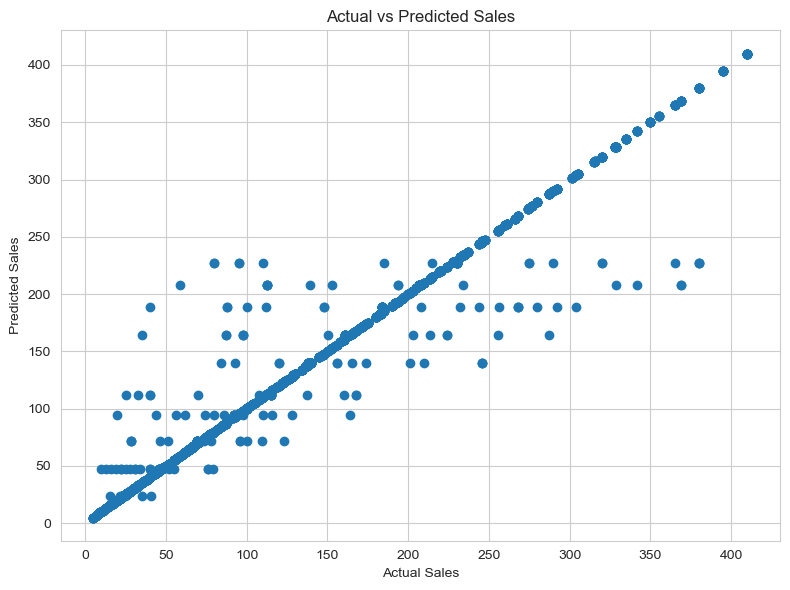

In [16]:
# Plot actual vs predicted values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.tight_layout()

plt.savefig("../visualizations/real_world_actual_vs_predicted.png")

plt.show()

# Feature Importance

          Feature  Importance
1        Quantity    0.516334
0  Price Per Unit    0.483666


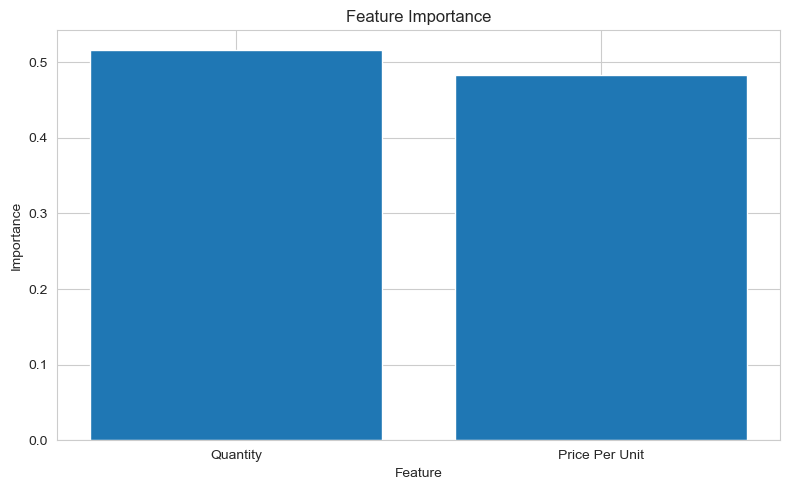

In [17]:
# Get feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

# Plot feature importance

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Feature")
plt.ylabel("Importance")

plt.tight_layout()

plt.savefig("../visualizations/real_world_feature_importance.png")

plt.show()

## Business Insights

1. The analysis shows differences in sales performance across product categories.

2. The monthly sales analysis helps identify variations in sales over time.

3. Payment method analysis provides an understanding of customer transaction preferences.

4. Location-level analysis helps identify differences in transaction activity.

5. Correlation analysis shows the relationship between price, quantity, and total spending.

6. The machine learning model was trained to predict total spending using price per unit and quantity.

7. Model performance was evaluated using MAE, RMSE, and R² score.

8. Feature importance helps identify which input variables contribute more to the prediction.

## Conclusion

This project demonstrates an end-to-end real-world retail data science workflow.

The project includes data cleaning, exploratory data analysis, visualization, statistical analysis, correlation analysis, and machine learning prediction.

The analysis helps understand sales patterns, customer transaction behavior, category performance, location activity, and relationships between numerical variables.

A Random Forest Regression model was developed to predict total spending using available sales-related features.

Overall, this project demonstrates how data science techniques can be applied to a real-world retail business dataset to generate analytical insights and predictive results.